<a href="https://colab.research.google.com/github/inward481/Numerico-criminalidad-en-ecuaciones-diferenciales-con-retardo/blob/main/DelfinTDa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install networkx numpy scipy pandas gudhi python-igraph scikit-image scikit-learn persim ripser tensorflow giotto-tda --quiet

In [ ]:
import glob
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

#ID Arrarys
ID_pacienta = []

# === PATHS ===
graphml_folder = "/content/drive/MyDrive/Datos/Conenectomas"
save_folder = "/content/drive/MyDrive/Datos/conectoma_matrix"

# Crear carpeta si no existe
os.makedirs(save_folder, exist_ok=True)

# === Función para convertir graphml a matriz normalizada ===
def graphml_to_matrix(path):
    G = nx.read_graphml(path)

    nodes = list(G.nodes())
    n = len(nodes)
    mat = np.zeros((n, n))

    # Llenar matriz con number_of_fibers
    for u, v, data in G.edges(data=True):
        if "number_of_fibers" in data:
            value = float(data["number_of_fibers"])
        else:
            value = 0.0
        i, j = nodes.index(u), nodes.index(v)
        mat[i, j] = value
        mat[j, i] = value  # hacerla simétrica

    # Eliminar autoconexiones
    np.fill_diagonal(mat, 0)

    # Normalización Min-Max
    if mat.max() > 0:
        mat = mat / mat.max()

    return mat


# === Procesar todos los .graphml ===
files = glob.glob(os.path.join(graphml_folder, "*.graphml"))
print(f"Encontrados {len(files)} conectomas.")

for f in files:
    mat = graphml_to_matrix(f)

    # Guardar .npy con el nombre modificado
    # Obtenemos el nombre base (ej: 100206_repeated10_scale125)
    base_name = os.path.splitext(os.path.basename(f))[0]

    # Extraemos solo el ID (ej: 100206)
    name = base_name.split('_')[0]
    # Guardar los ID en un array
    ID_pacienta.append(int(name))

    # Guardamos como ID.npy
    np.save(os.path.join(save_folder, f"{name}.npy"), mat)

print("✅ Conversión completa. Matrices guardadas en:", save_folder)


Encontrados 1064 conectomas.
✅ Conversión completa. Matrices guardadas en: /content/drive/MyDrive/Datos/conectoma_matrix


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mostrando las primeras 3 matrices de 1064 encontradas...
------------------------------


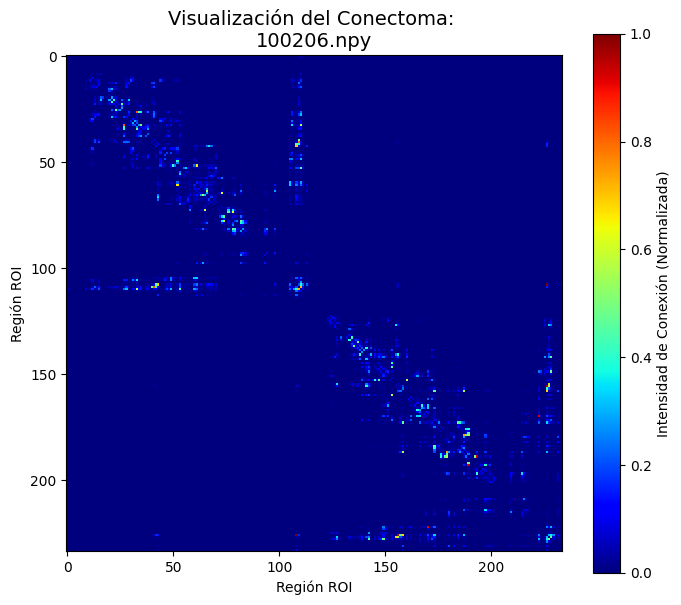

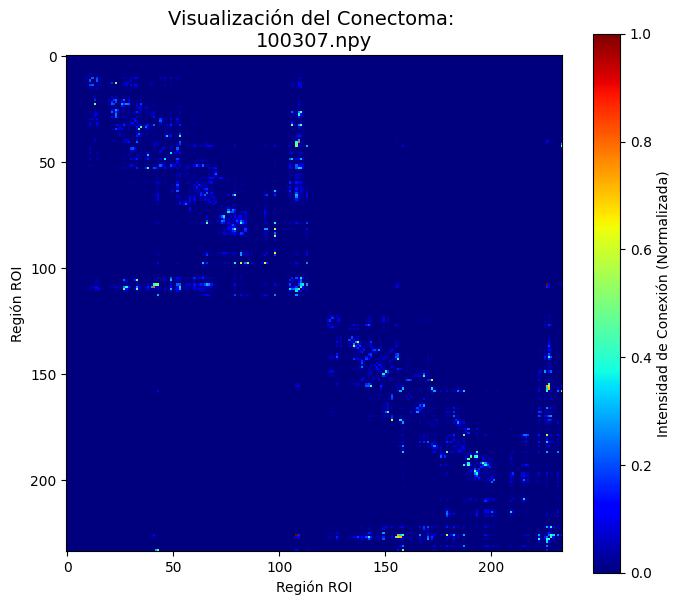

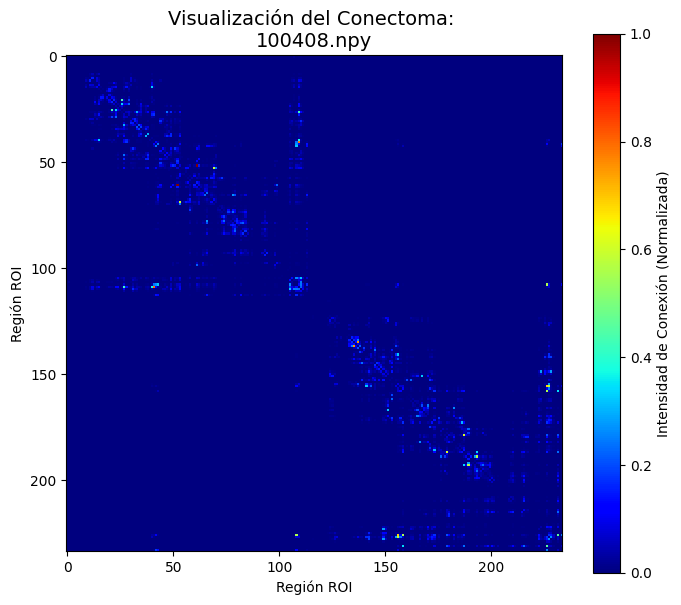

In [ ]:
from google.colab import drive

# --- 1. Montar Google Drive ---
# Esto te pedirá autorización para acceder a tus archivos
drive.mount('/content/drive')

# --- 2. Definir la ruta y buscar los archivos ---
# Ruta a la carpeta que contiene tus matrices
data_path = "/content/drive/MyDrive/Datos/conectoma_matrix/"

# Usamos glob para encontrar todos los archivos .npy en esa carpeta
# Asegúrate de que la carpeta 'conectoma_matrix' exista en esa ruta
all_matrix_files = glob.glob(os.path.join(data_path, "*.npy"))

# Ordenamos los archivos por nombre (opcional, pero da consistencia)
all_matrix_files.sort()

# --- 3. Seleccionar y visualizar las primeras 3 matrices ---
# Seleccionamos solo los primeros 3 archivos de la lista
files_to_visualize = all_matrix_files[:3]

if not files_to_visualize:
    print(f"Error: No se encontraron archivos .npy en la ruta: {data_path}")
else:
    print(f"Mostrando las primeras {len(files_to_visualize)} matrices de {len(all_matrix_files)} encontradas...")
    print("-" * 30)

    # Iteramos sobre los 3 archivos seleccionados
    for file_path in files_to_visualize:
        try:
            # Cargar la matriz desde el archivo .npy
            connectome_matrix = np.load(file_path)

            # Extraer el nombre del archivo para el título
            file_name = os.path.basename(file_path)

            # --- Graficar la matriz ---
            plt.figure(figsize=(8, 7))

            # Usamos imshow con el colormap 'jet' para un look similar al de tu imagen
            # (azul para valores bajos, rojo/amarillo para valores altos)
            cax = plt.imshow(connectome_matrix, cmap='jet', interpolation='nearest')

            # Añadir una barra de color para ver la escala
            plt.colorbar(cax, label='Intensidad de Conexión (Normalizada)')

            # Poner el título
            plt.title(f"Visualización del Conectoma: \n{file_name}", fontsize=14)

            # Ocultar los ejes (opcional, para un look más limpio)
            # plt.axis('off')

            plt.xlabel("Región ROI")
            plt.ylabel("Región ROI")

            # Mostrar el gráfico
            plt.show()

        except Exception as e:
            print(f"Error al cargar o graficar el archivo {file_path}: {e}")

In [ ]:


# --- 1. Montar Drive y definir rutas ---
# (Asegúrate de haber corrido drive.mount('/content/drive') antes)
data_path = "/content/drive/MyDrive/Datos/conectoma_matrix/"
all_matrix_files = sorted(glob.glob(os.path.join(data_path, "*.npy")))

if len(all_matrix_files) < 2:
    print(f"Error: Se necesitan al menos 2 archivos para comparar.")
else:
    # --- 2. Cargar las primeras dos matrices ---
    file1 = all_matrix_files[0]
    file2 = all_matrix_files[1]

    print(f"Comparando '{os.path.basename(file1)}' y '{os.path.basename(file2)}'...")

    matrix_A = np.load(file1)
    matrix_B = np.load(file2)

    # --- 3. Comprobar si son IDÉNTICAS ---
    if np.array_equal(matrix_A, matrix_B):
        print("Las matrices son numéricamente IDÉNTICAS.")
        print("Esto es un problema para el entrenamiento. Revisa tu script de conversión.")
    else:
        print("Las matrices NO son idénticas.")

        # --- 4. Ver CUÁN diferentes son ---
        # Calculamos la diferencia absoluta máxima
        max_diff = np.max(np.abs(matrix_A - matrix_B))
        # Calculamos la diferencia media
        mean_diff = np.mean(np.abs(matrix_A - matrix_B))

        print(f"  > Diferencia media absoluta: {mean_diff:.10f}")
        print(f"  > Diferencia máxima absoluta: {max_diff:.10f}")


Comparando '100206.npy' y '100307.npy'...
Las matrices NO son idénticas.
  > Diferencia media absoluta: 0.0040114919
  > Diferencia máxima absoluta: 0.7035024343


In [ ]:
import pandas as pd

# Define la ruta de tu archivo
ruta_archivo = '/content/drive/MyDrive/Datos/HCP_YA_subjects_2025_11_02_15_37_05.csv'

# Define la lista de columnas que quieres cargar
columnas_deseadas = ['Subject','Gender', 'Age', 'CogFluidComp_AgeAdj', 'NEOFAC_N', 'PSQI_Score']

# Lee el CSV usando 'usecols' para cargar solo esas columnas
df_infoConnectome = pd.read_csv(ruta_archivo, usecols=columnas_deseadas)

# Asumiendo que 'ID_pacienta' ya existe y es tu lista de IDs (ej: [100307, 100408, 100610])
df_infoConnectome = df_infoConnectome[df_infoConnectome['Subject'].isin(ID_pacienta)]

# Lista de las columnas que quieres rellenar con su media
columnas_a_imputar = ['CogFluidComp_AgeAdj', 'NEOFAC_N']

# Calculamos la media de esas columnas y rellenamos los NaNs
df_infoConnectome[columnas_a_imputar] = df_infoConnectome[columnas_a_imputar].fillna(
    df_infoConnectome[columnas_a_imputar].mean()
)

# Opcional: verifica el DataFrame (ahora filtrado)
print(df_infoConnectome.head(10))
# Contamos los valores únicos en la columna 'Gender'
print("Conteo de Género: ", df_infoConnectome['Gender'].value_counts())
#info data base
df_infoConnectome.info()

    Subject Gender    Age  PSQI_Score  CogFluidComp_AgeAdj  NEOFAC_N
0    192641      F  31-35           5           119.920000      14.0
1    111514      M  31-35           0           105.966857      20.0
2    175540      M  31-35           3           105.250000      10.0
3    146129      M  22-25           1           138.800000      11.0
4    512835      M  31-35           4           101.240000      27.0
5    105923      F  31-35           2            94.520000      11.0
6    104012      F  26-30           4            79.700000      19.0
7    153732      F  26-30           4            87.440000      15.0
8    783462      M  22-25           2           127.130000       7.0
10   715950      F  26-30           2           116.390000      14.0
Conteo de Género:  Gender
F    575
M    489
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 1064 entries, 0 to 1205
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------         

In [ ]:
# --- 0. Importaciones Adicionales ---
# (Asegúrate de tener estas importaciones al inicio de tu script)
import numpy as np
import os
import glob
# (Asumo que pandas ya está importado y df_infoConnectome cargado)
# import pandas as pd

# ¡IMPORTANTE! Importamos la función para dividir los datos
from sklearn.model_selection import train_test_split


# --- 1. Preparar datos (Tu código original, sin cambios) ---

# Asegurar que el ID en el CSV sea string
df_infoConnectome['Subject'] = df_infoConnectome['Subject'].astype(str)

# Diccionario de Scores: {ID_Subject: Valor_Score}
score_dict = df_infoConnectome.set_index('Subject')['CogFluidComp_AgeAdj'].to_dict()

# Diccionario de Archivos: {ID_Archivo: /ruta/completa.npy}
# (Asegúrate que la ruta '/content/drive/...' sea correcta)
all_files = glob.glob(os.path.join('/content/drive/MyDrive/Datos/conectoma_matrix', "*.npy"))
file_dict = {os.path.splitext(os.path.basename(f))[0]: f for f in all_files}


# --- 2. Encontrar la intersección (Tu código original, sin cambios) ---
common_ids = file_dict.keys() & score_dict.keys()

print(f"Encontrados {len(all_files)} archivos y {len(score_dict)} sujetos en CSV.")
print(f"Cargando {len(common_ids)} conectomas con datos coincidentes.")


# --- 3. Construir X (features) y y (labels) para el CONJUNTO COMPLETO ---
# Nota: Renombramos las listas a "_all_list" para mayor claridad

# Lista para TODAS las matrices (X)
X_all_list = []
# Lista para TODOS los scores (y)
y_all_list = []

for id_ in common_ids:
    # Cargar la matriz
    matriz = np.load(file_dict[id_])

    # guardar las matrices
    X_all_list.append(matriz)
    y_all_list.append(score_dict[id_])


# --- 4. Convertir a NumPy Arrays finales (CONJUNTO COMPLETO) ---
# Renombramos a X_all / y_all

# Usamos float32 para eficiencia en GPU
X_all = np.array(X_all_list, dtype=np.float32)
y_all = np.array(y_all_list, dtype=np.float32)

print("\n--- ¡Conjunto de datos completo cargado! ---")
print(f"Shape de X_all (features totales): {X_all.shape}")
print(f"Shape de y_all (labels totales):  {y_all.shape}")


# --- 5. ¡NUEVO! Dividir en Entrenamiento (Train) y Prueba (Test) ---

# Definimos el número de muestras para el test (como pediste)
TEST_SIZE_COUNT = 64

# Usamos un estado aleatorio (ej. 42) para que la división sea
# REPRODUCIBLE. Si vuelves a correr el código, la división
# será la misma. Puedes usar cualquier número.
RANDOM_STATE = 42

# Usamos train_test_split para hacer la magia.
# test_size=TEST_SIZE_COUNT (un entero) le dice que queremos exactamente 34 muestras.
# shuffle=True (que es el default) es importante para que la división sea aleatoria.
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=TEST_SIZE_COUNT,
    random_state=RANDOM_STATE
)

# --- 6. Verificación Final ---
print("\n--- ¡Datos divididos y listos para la CNN! ---")
print(f"Shape de X_train (entrenamiento): {X_train.shape}")
print(f"Shape de y_train (entrenamiento):  {y_train.shape}")
print(f"Shape de X_test (prueba):     {X_test.shape}")
print(f"Shape de y_test (prueba):      {y_test.shape}")


Encontrados 1064 archivos y 1064 sujetos en CSV.
Cargando 1064 conectomas con datos coincidentes.

--- ¡Conjunto de datos completo cargado! ---
Shape de X_all (features totales): (1064, 234, 234)
Shape de y_all (labels totales):  (1064,)

--- ¡Datos divididos y listos para la CNN! ---
Shape de X_train (entrenamiento): (1000, 234, 234)
Shape de y_train (entrenamiento):  (1000,)
Shape de X_test (prueba):     (64, 234, 234)
Shape de y_test (prueba):      (64,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv1D, Lambda, concatenate
from tensorflow.keras.utils import plot_model


# --- 2a. Parámetros del Modelo ---

# ¡El número de nodos se toma directamente de tus datos!
num_nodes = X_train.shape[1]  # Esto será 234

# Hiperparámetros que puedes ajustar luego
e2n_filters = 32  # Filtros para la capa Edge-to-Node
n2g_filters = 64  # Filtros para la capa Node-to-Graph
dense_units = 128 # Neuronas en la capa oculta final

print(f"Construyendo BrainNetCNN para {num_nodes} nodos.")

# --- 2b. Capa de Entrada ---
# La entrada es una matriz de conectividad
input_tensor = Input(shape=(num_nodes, num_nodes))

# --- 2c. Capa E2N (Edge-to-Node) ---
# Leemos las conexiones de cada nodo (filas y columnas)

# Convolución por filas (conexiones "desde" un nodo)
conv_rows = Conv1D(filters=e2n_filters, kernel_size=1, activation='relu')(input_tensor)
# Shape resultante: (None, 234, 32)

# Convolución por columnas (conexiones "hacia" un nodo)
# Primero transponemos la matriz (cambiamos filas por columnas)
transposed_input = Lambda(lambda x: tf.transpose(x, perm=[0, 2, 1]))(input_tensor)
conv_cols = Conv1D(filters=e2n_filters, kernel_size=1, activation='relu')(transposed_input)
# Shape resultante: (None, 234, 32)

# Concatenamos las características de filas y columnas
e2n_features = concatenate([conv_rows, conv_cols], axis=-1)
# Shape resultante: (None, 234, 64) (porque 32 + 32 = 64)

# --- 2d. Capa N2G (Node-to-Graph) ---
# Agregamos todas las características de los nodos en UN solo vector para el cerebro
conv_graph = Conv1D(filters=n2g_filters, kernel_size=num_nodes, activation='relu')(e2n_features)
# Shape resultante: (None, 1, 64)

# Eliminamos la dimensión extra
graph_features = Lambda(lambda x: tf.squeeze(x, axis=1))(conv_graph)
# Shape resultante: (None, 64)

# --- 2e. Capas Finales (Regresión) ---
# Usamos el vector del cerebro para predecir el valor
dense_layer = Dense(dense_units, activation='relu')(graph_features)

# ¡CAPA DE SALIDA PARA REGRESIÓN!
# Una sola neurona (Dense(1))
# Activación 'linear' (significa que no hay activación, la salida es el número directo)
output_layer = Dense(1, activation='linear')(dense_layer)

# --- 2f. Crear el Modelo ---
model = Model(inputs=input_tensor, outputs=output_layer)

# Imprimir el resumen de la arquitectura
model.summary()

Construyendo BrainNetCNN para 234 nodos.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 234, 234)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 234, 234)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 234, 32)   │      7,520 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 234, 32)   │      7,520 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 234, 64)   │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1, 64)     │    958,528 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 64)        │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      8,320 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 982,017 (3.75 MB)

 Trainable params: 982,017 (3.75 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',  # Un optimizador robusto y popular
    loss='mean_squared_error', # ¡Clave para regresión!
    metrics=['mae'] # ¡Clave para regresión!
)

print("\nModelo compilado para regresión (loss=mse, metric=mae).")
print("Iniciando el entrenamiento...")

# Guardamos el historial para poder ver cómo aprendió
history = model.fit(
    X_train,
    y_train,
    epochs=50,          # 50 "vueltas" a los datos. Puedes ajustar esto.
    batch_size=32,      # Procesar de 32 en 32 muestras.
    validation_split=0.2 # ¡Importante! Usar 20% para validar
)

print("¡Entrenamiento completado!")


Modelo compilado para regresión (loss=mse, metric=mae).
Iniciando el entrenamiento...
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 11062.8135 - mae: 103.3390 - val_loss: 2901.4482 - val_mae: 50.9771
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1242.2673 - mae: 29.5547 - val_loss: 585.3892 - val_mae: 19.8757
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 435.5035 - mae: 16.7852 - val_loss: 364.1529 - val_mae: 15.0437
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 402.7038 - mae: 15.8402 - val_loss: 346.4345 - val_mae: 14.7125
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 377.7991 - mae: 15.7590 - val_loss: 328.5057 - val_mae: 14.4014
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 347.0757 - mae: 15.2586 - val_loss: 326.3041 - val_mae: 14.4706
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 359.4722 - mae: 15.2504 - val_loss: 324.4074 - val_mae: 14.5458
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/ste

In [ ]:

import numpy as np

def predecir_conectoma(conectoma, modelo):
    """
    Predice el valor de un solo conectoma usando el modelo entrenado.

    Argumentos:
    conectoma (np.array): Una matriz 2D de conectividad (ej. de forma (234, 234)).
    modelo (keras.Model): El modelo de Keras/TensorFlow ya entrenado.

    Devuelve:
    float: El valor de la predicción (escalar).
    """

    # 1. Asegurar que la entrada sea un array de NumPy (opcional pero seguro)
    conectoma = np.asarray(conectoma)

    # 2. Añadir la dimensión del "batch"
    # El modelo espera una forma (lote, alto, ancho) -> (1, 234, 234)
    conectoma_expandido = np.expand_dims(conectoma, axis=0)

    # 3. Realizar la predicción
    prediccion_raw = modelo.predict(conectoma_expandido)

    # 4. Extraer el valor escalar de la predicción
    # prediccion_raw tiene forma (1, 1), extraemos el valor
    valor_predicho = prediccion_raw[0][0]

    return valor_predicho

# 1. Seleccionamos una muestra (p.ej., el primer conectoma del set de prueba)
muestra_para_predecir = X_test[0]
valor_real = y_test[0]  # Etiqueta real correspondiente a esa muestra

# 2. Llamamos a nuestra nueva función
prediccion_escalar = predecir_conectoma(muestra_para_predecir, model)

# 3. Vemos el resultado
print(f"Forma del conectoma de entrada: {muestra_para_predecir.shape}")
print("\n--- Resultados de la Predicción ---")
print(f"Predicción del modelo: {prediccion_escalar:.2f}")
print(f"Valor real:            {valor_real:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step
Forma del conectoma de entrada: (234, 234)

--- Resultados de la Predicción ---
Predicción del modelo: 107.23
Valor real:            142.08


In [ ]:
from sklearn.metrics import confusion_matrix, r2_score, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt

#guardando prediciones
prediccion_label = []

#prediccion de cada uno de los conectomas para testiar
for conectome_ in X_test:
  score_pre = predecir_conectoma(conectome_, model)
  prediccion_label.append(score_pre)

# Crear el gráfico de puntos sin unir
plt.figure(figsize=(8, 8))
plt.scatter(y_test, prediccion_label, alpha=0.6, label='Predicción vs. Valor Verdadero')

# 1. Definir los límites para la línea de acuerdo perfecto (y=x)
min_val = min(min(y_test), min(prediccion_label))
max_val = max(max(y_test), max(prediccion_label))
margin = (max_val - min_val) * 0.05
min_lim = min_val - margin
max_lim = max_val + margin

# 2. Dibujar la línea de acuerdo perfecto
plt.plot([min_lim, max_lim], [min_lim, max_lim], 'r--', label='Acuerdo Perfecto ($y=x$)')

# 3. Configuración del gráfico
plt.title('Comparación de Valores Predichos vs. Valores Verdaderos')
plt.xlabel('Valores Verdaderos ($y_{test}$)')
plt.ylabel('Valores Predichos ($prediccion\_label$)')
plt.xlim(min_lim, max_lim)
plt.ylim(min_lim, max_lim)
plt.legend()
plt.grid(True)
plt.show()


# --- Bloque de Cálculo de Métricas ---

# 1. R^2 (Coeficiente de Determinación)
# Mide la proporción de la varianza en la variable dependiente que es predecible
# a partir de las variables independientes. Un valor más cercano a 1.0 es mejor.
r_squared = r2_score(y_test, prediccion_label)

# 2. MAE (Error Absoluto Medio)
# Mide el error promedio de las predicciones en las unidades de la variable de salida.
# Es una métrica robusta ante outliers. Un valor más cercano a 0.0 es mejor.
mae = mean_absolute_error(y_test, prediccion_label)

# --- Bloque de Salida (Resultados) ---

# Se utiliza f-strings para un formato de salida limpio y se redondea a 4 decimales.
print("--- Métricas de Rendimiento de Regresión ---")
print(f"R-cuadrado (R2):         {r_squared:.4f}")
print(f"Error Absoluto Medio (MAE): {mae:.4f}")

# Nota: Si el modelo es muy simple o tiene pocos datos, el R2 puede ser negativo,
# lo que indica que el modelo es peor que simplemente predecir la media.


In [ ]:
# --- IMPORTS NECESARIOS ---
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Imports de TDA (Giotto-TDA)
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Scaler, BettiCurve

# Imports del Modelo (Keras)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, concatenate, Dropout, BatchNormalization, Flatten,
    Conv1D, Conv2D,
    Permute, Add, Activation,
    Reshape
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------------------------------------------------
# FUNCIÓN 1: EXTRACCIÓN DE CARACTERÍSTICAS TDA (Sin Cambios)
# -------------------------------------------------------------------

def extract_tda_features(connectomes):
    """
    Pipeline TDA v3: Usa BettiCurve para obtener (N, 2, 200) características.
    """
    print("Transformando conectomas a matrices de distancia (1 - abs(X))...")
    X_dist = 1.0 - np.abs(connectomes)

    for i in range(X_dist.shape[0]):
        np.fill_diagonal(X_dist[i], 0)

    X_dist = np.nan_to_num(X_dist, nan=1.0, posinf=1.0, neginf=1.0)

    homology_dimensions = (0, 1)
    n_bins_betti = 200

    tda_pipeline = Pipeline([
        ('persistence', VietorisRipsPersistence(
            metric="precomputed",
            homology_dimensions=homology_dimensions,
            n_jobs=-1
        )),
        ('scaling', Scaler(n_jobs=-1)),
        ('vectorization', BettiCurve(n_bins=n_bins_betti, n_jobs=-1))
    ])

    print("Iniciando extracción TDA (con BettiCurve)...")
    X_tda = tda_pipeline.fit_transform(X_dist)
    print(f"Extracción TDA completa. Forma de características: {X_tda.shape}")

    return X_tda

# -------------------------------------------------------------------
# FUNCIÓN 2: CREACIÓN DEL MODELO HÍBRIDO (¡OPTIMIZADO!)
# -------------------------------------------------------------------

def create_hybrid_model(tda_input_shape, connectome_input_shape=(234, 234, 1)):
    """
    Construye el modelo híbrido v8: TDA + BrainNetCNN (Real)

    - OPTIMIZACIÓN: Tasa de aprendizaje (learning rate) reducida
    - para un entrenamiento más estable y cuidadoso.
    - Regularización revertida a L2=0.01.
    """

    NUM_NODES = connectome_input_shape[0] # 234

    # Revertimos al L2 original (más bajo)
    reg = l2(0.01)

    # --- Rama 1: BrainNetCNN (Arquitectura Kawahara) ---
    cnn_input = Input(shape=connectome_input_shape, name="cnn_input")

    # --- Capa 1: Edge-to-Node (E2N) ---
    e2n_row = Conv2D(32, (1, NUM_NODES), activation='linear', kernel_regularizer=reg)(cnn_input)
    e2n_col = Conv2D(32, (NUM_NODES, 1), activation='linear', kernel_regularizer=reg)(cnn_input)
    e2n_col_permuted = Permute((2, 1, 3))(e2n_col)

    e2n_features = Add()([e2n_row, e2n_col_permuted])
    e2n_features = BatchNormalization()(e2n_features)
    e2n_features = Activation('relu')(e2n_features)

    e2n_squeezed = Reshape((NUM_NODES, 32))(e2n_features)

    # --- Capa 2: Node-to-Graph (N2G) ---
    n2g_features = Conv1D(64, NUM_NODES, activation='linear', kernel_regularizer=reg)(e2n_squeezed)
    n2g_features = BatchNormalization()(n2g_features)
    n2g_features = Activation('relu')(n2g_features)

    n2g_squeezed = Reshape((64,))(n2g_features)

    # Revertimos al Dropout original
    cnn_features = Dropout(0.5)(n2g_squeezed)

    # --- Rama 2: TDA (Topología) ---
    tda_input = Input(shape=tda_input_shape, name="tda_input") # (None, 2, 200)

    y = Flatten(name="tda_flatten")(tda_input) # (None, 400)

    y = Dense(64, activation='relu', kernel_regularizer=reg)(y)
    y = BatchNormalization()(y)

    # Revertimos al Dropout original
    tda_features = Dropout(0.4)(y)

    # --- Fusión y Cabezal de Regresión ---
    combined_features = concatenate([cnn_features, tda_features], name="fusion")

    z = Dense(128, activation='relu', kernel_regularizer=reg)(combined_features)

    # Revertimos al Dropout original
    z = Dropout(0.5)(z)

    z = Dense(64, activation='relu', kernel_regularizer=reg)(z)

    output = Dense(1, name="output")(z)

    # --- Compilar Modelo ---
    model = Model(inputs=[cnn_input, tda_input], outputs=[output], name="TDA_Real_BrainNetCNN_v8_LowLR")

    # --- CAMBIO: Tasa de aprendizaje más baja ---
    optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5) # Antes 1e-4
    # ---------------------------------------------

    model.compile(optimizer=optimizer,
                  loss='mse',
                  metrics=['mae'])

    return model

# ===================================================================
# SCRIPT PRINCIPAL DE EJECUCIÓN (Sin Cambios)
# ===================================================================

print("--- Iniciando Flujo de Trabajo Híbrido TDA + BrainNetCNN (LR Bajo) ---")

# --- (AQUÍ CARGAS TUS DATOS) ---
# X_train = ...
# y_train = ...
# X_test = ...
# y_test = ...
# ---------------------------------

# --- PASO 1: Normalizar la variable objetivo 'y' ---
print("\n--- PASO 1: Escalando 'y' (target) ---")
y_train_reshaped = y_train.reshape(-1, 1)
y_test_reshaped = y_test.reshape(-1, 1)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train_reshaped)
y_test_scaled = y_scaler.transform(y_test_reshaped)
print(f"Forma 'y' escalada (train): {y_train_scaled.shape}")


# --- PASO 2: Extraer Características TDA ---
print("\n--- PASO 2: Extrayendo Características TDA ---")
X_train_tda = extract_tda_features(X_train)
X_test_tda = extract_tda_features(X_test)


# --- PASO 3: Preparar datos de la CNN ---
print("\n--- PASO 3: Preparando Datos CNN ---")
X_train_cnn = np.expand_dims(X_train, axis=-1)
X_test_cnn = np.expand_dims(X_test, axis=-1)
print(f"Forma CNN (train): {X_train_cnn.shape}")


# --- PASO 4: Construir y Entrenar el Modelo ---
print("\n--- PASO 4: Construyendo el Modelo Optimizado (LR Bajo) ---")
TDA_INPUT_SHAPE = (X_train_tda.shape[1], X_train_tda.shape[2])
CNN_INPUT_SHAPE = (X_train_cnn.shape[1], X_train_cnn.shape[2], X_train_cnn.shape[3])

model = create_hybrid_model(tda_input_shape=TDA_INPUT_SHAPE,
                            connectome_input_shape=CNN_INPUT_SHAPE)
model.summary()

# Preparar las entradas
input_data_train = {
    "cnn_input": X_train_cnn,
    "tda_input": X_train_tda
}
input_data_test = {
    "cnn_input": X_test_cnn,
    "tda_input": X_test_tda
}

# Aumentamos la paciencia. Un LR más bajo puede tardar más en converger.
early_stopping = EarlyStopping(monitor='val_loss',
                              patience=25, # Antes 20
                              restore_best_weights=True)

print("\n--- Iniciando Entrenamiento ---")
history = model.fit(
    input_data_train,
    y_train_scaled,
    validation_data=(input_data_test, y_test_scaled),
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping]
)


# --- PASO 5: Evaluar el Modelo ---
print("\n--- PASO 5: Evaluación Final ---")

loss_scaled, mae_scaled = model.evaluate(input_data_test, y_test_scaled)
print(f"Resultados (escalados):")
print(f"  Loss (MSE) escalado: {loss_scaled:.4f}")
print(f"  MAE escalado:          {mae_scaled:.4f}")

y_pred_scaled = model.predict(input_data_test)
y_pred_original = y_scaler.inverse_transform(y_pred_scaled)

original_mae = np.mean(np.abs(y_test - y_pred_original.flatten()))
print("\nResultados (en la escala original 'CogFluidComp_AgeAdj'):")
print(f"  **MAE Original (Test): {original_mae:.4f}**")

print("\n--- ¡Flujo de Trabajo Completo! ---")

--- Iniciando Flujo de Trabajo Híbrido TDA + BrainNetCNN (LR Bajo) ---

--- PASO 1: Escalando 'y' (target) ---
Forma 'y' escalada (train): (1000, 1)

--- PASO 2: Extrayendo Características TDA ---
Transformando conectomas a matrices de distancia (1 - abs(X))...
Iniciando extracción TDA (con BettiCurve)...
Extracción TDA completa. Forma de características: (1000, 2, 200)
Transformando conectomas a matrices de distancia (1 - abs(X))...
Iniciando extracción TDA (con BettiCurve)...
Extracción TDA completa. Forma de características: (64, 2, 200)

--- PASO 3: Preparando Datos CNN ---
Forma CNN (train): (1000, 234, 234, 1)

--- PASO 4: Construyendo el Modelo Optimizado (LR Bajo) ---


Model: "TDA_Real_BrainNetCNN_v8_LowLR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_input           │ (None, 234, 234,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 1, 234,    │      7,520 │ cnn_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 234, 1,    │      7,520 │ cnn_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 234, 1,    │          0 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 234, 1,    │          0 │ conv2d[0][0],     │
│                     │ 32)               │            │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 234, 1,    │        128 │ add[0][0]         │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 234, 1,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 234, 32)   │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1, 64)     │    479,296 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tda_input           │ (None, 2, 200)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 64)     │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tda_flatten         │ (None, 400)       │          0 │ tda_input[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1, 64)     │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     25,664 │ tda_flatten[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 64)        │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 128)       │          0 │ dropout[0][0],  

 Total params: 545,473 (2.08 MB)

 Trainable params: 545,153 (2.08 MB)

 Non-trainable params: 320 (1.25 KB)


--- Iniciando Entrenamiento ---
Epoch 1/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 161ms/step - loss: 5.3019 - mae: 1.0261 - val_loss: 411.9387 - val_mae: 20.1750
Epoch 2/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.1106 - mae: 0.9643 - val_loss: 120.3598 - val_mae: 10.7597
Epoch 3/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.9743 - mae: 0.9628 - val_loss: 52.3205 - val_mae: 6.9209
Epoch 4/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4.7671 - mae: 0.9063 - val_loss: 21.6751 - val_mae: 4.1615
Epoch 5/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.8646 - mae: 0.9658 - val_loss: 9.9614 - val_mae: 2.4185
Epoch 6/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.6893 - mae: 0.8953 - val_loss: 4.5157 - val_mae: 0.8479
Epoch 7/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4.6512 - mae: 0.8902 - val_loss: 4.6915 - val_mae: 0.8641
Epoch 8/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4.5591 - mae: 0.8727 - val_loss: 5.5988 - val_mae: 1.2557
Epoch 9/150
3